In [1]:
import pandas as pd

counts = pd.read_csv(r"C:\Users\PC\spaceflight-rnaseq-analysis\count.csv")

print(counts.shape)

counts.head()

(57186, 13)


,Unnamed: 0,GSM5398358,GSM5398359,GSM5398360,GSM5398361,GSM5398362,GSM5398363,GSM5398364,GSM5398365,GSM5398366,GSM5398367,GSM5398368,GSM5398369
0,ENSMUSG00000000001,350,444,326,406,317,472,390,506,247,428,393,392
1,ENSMUSG00000000003,0,0,0,0,0,0,0,0,0,0,0,0
2,ENSMUSG00000000028,38,40,26,44,45,46,38,45,29,30,29,39
3,ENSMUSG00000000031,24081,20460,22997,16920,12757,16312,19580,21072,15590,16215,11767,12436
4,ENSMUSG00000000037,7,3,14,6,9,6,4,3,5,1,0,6


In [2]:
counts.columns

Index(['Unnamed: 0', 'GSM5398358', 'GSM5398359', 'GSM5398360', 'GSM5398361',
       'GSM5398362', 'GSM5398363', 'GSM5398364', 'GSM5398365', 'GSM5398366',
       'GSM5398367', 'GSM5398368', 'GSM5398369'],
      dtype='str')

In [3]:
counts = counts.rename(columns={"Unnamed: 0": "gene"})

counts.head()

,gene,GSM5398358,GSM5398359,GSM5398360,GSM5398361,GSM5398362,GSM5398363,GSM5398364,GSM5398365,GSM5398366,GSM5398367,GSM5398368,GSM5398369
0,ENSMUSG00000000001,350,444,326,406,317,472,390,506,247,428,393,392
1,ENSMUSG00000000003,0,0,0,0,0,0,0,0,0,0,0,0
2,ENSMUSG00000000028,38,40,26,44,45,46,38,45,29,30,29,39
3,ENSMUSG00000000031,24081,20460,22997,16920,12757,16312,19580,21072,15590,16215,11767,12436
4,ENSMUSG00000000037,7,3,14,6,9,6,4,3,5,1,0,6


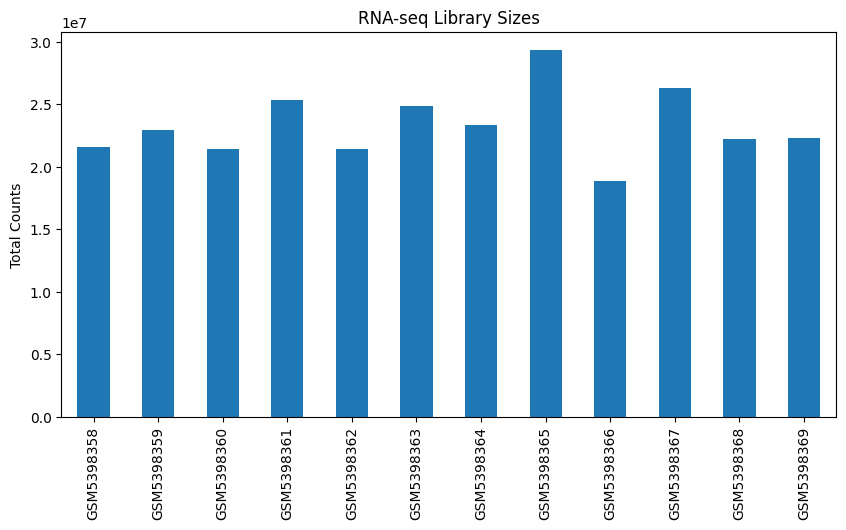

In [4]:
import matplotlib.pyplot as plt

sample_sums = counts.iloc[:, 1:].sum()

plt.figure(figsize=(10,5))
sample_sums.plot(kind="bar")

plt.ylabel("Total Counts")
plt.title("RNA-seq Library Sizes")

plt.show()

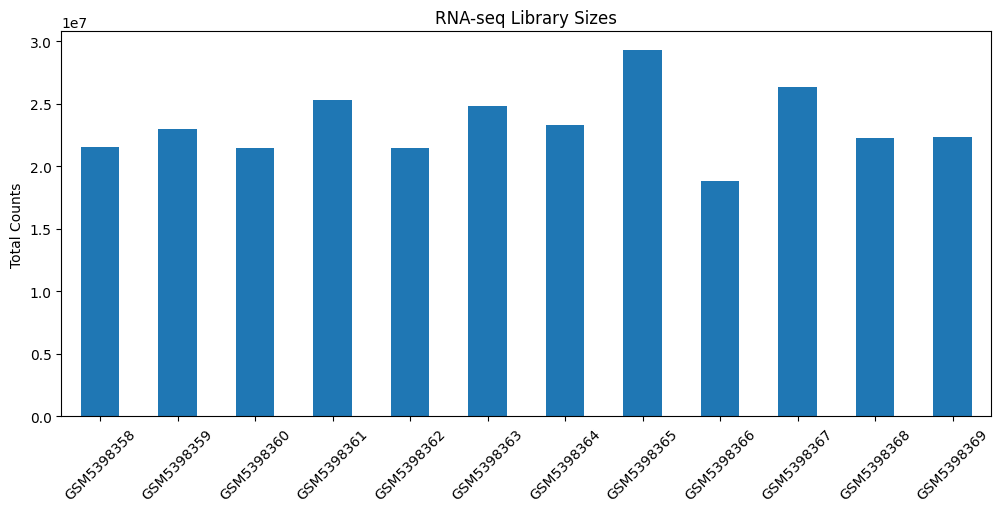

In [5]:
import matplotlib.pyplot as plt

sample_sums = counts.iloc[:, 1:].sum()

plt.figure(figsize=(12,5))
sample_sums.plot(kind="bar")

plt.ylabel("Total Counts")
plt.title("RNA-seq Library Sizes")

plt.xticks(rotation=45)

plt.show()

In [6]:
import numpy as np

genes = counts["gene"]

numeric_data = counts.iloc[:, 1:].astype(float)

log_numeric = np.log1p(numeric_data)

log_counts = pd.concat([genes, log_numeric], axis=1)

log_counts.head()

,gene,GSM5398358,GSM5398359,GSM5398360,GSM5398361,GSM5398362,GSM5398363,GSM5398364,GSM5398365,GSM5398366,GSM5398367,GSM5398368,GSM5398369
0,ENSMUSG00000000001,5.860786,6.098074,5.789960,6.008813,5.762051,6.159095,5.968708,6.228511,5.513429,6.061457,5.976351,5.973810
1,ENSMUSG00000000003,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,ENSMUSG00000000028,3.663562,3.713572,3.295837,3.806662,3.828641,3.850148,3.663562,3.828641,3.401197,3.433987,3.401197,3.688879
3,ENSMUSG00000000031,10.089220,9.926276,10.043163,9.736311,9.453914,9.699718,9.882315,9.955748,9.654449,9.693754,9.373139,9.428431
4,ENSMUSG00000000037,2.079442,1.386294,2.708050,1.945910,2.302585,1.945910,1.609438,1.386294,1.791759,0.693147,0.000000,1.945910


In [7]:
from sklearn.decomposition import PCA

X = log_counts.iloc[:, 1:].T

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X)

print(pca_result)

[[   9.87264548   21.63121973]
 [  20.1217417    11.81771533]
 [   2.94281559   11.94261056]
 [  26.22471497    3.68753286]
 [  21.98396533   33.8941838 ]
 [  30.0135797    17.31794157]
 [  -1.95847586  -13.8089583 ]
 [  12.92081126  -40.27918776]
 [-102.78520034   15.03999541]
 [  -2.31381266  -52.10298327]
 [ -12.75171772   -3.72472096]
 [  -4.27106744   -5.41534898]]


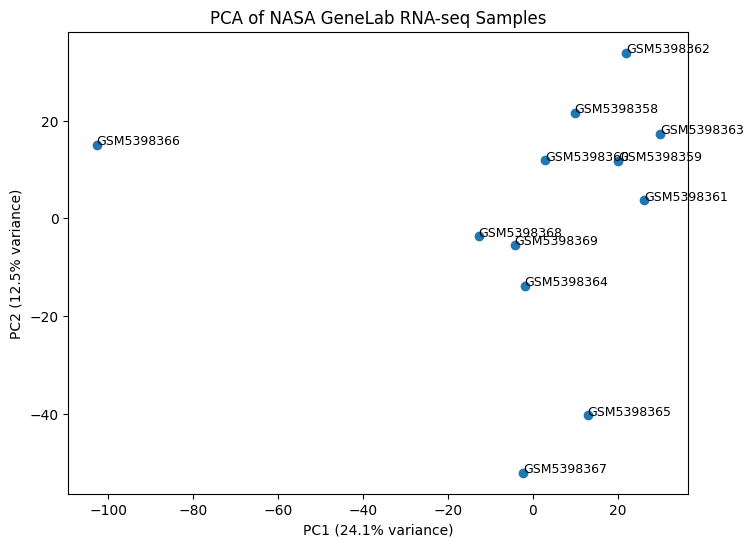

In [8]:
import matplotlib.pyplot as plt

samples = log_counts.columns[1:]

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])

for i, sample in enumerate(samples):
    plt.text(pca_result[i, 0], pca_result[i, 1], sample, fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of NASA GeneLab RNA-seq Samples")

plt.show()

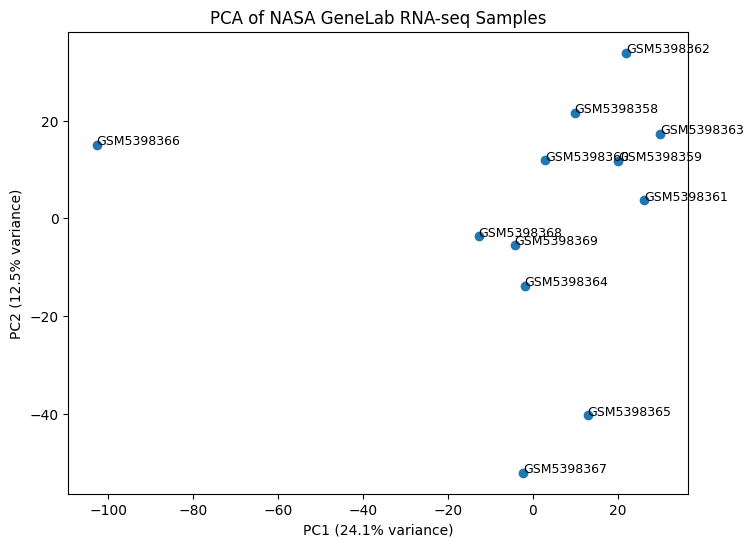

In [9]:
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1])

for i, sample in enumerate(samples):
    plt.text(pca_result[i,0], pca_result[i,1], sample, fontsize=9)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA of NASA GeneLab RNA-seq Samples")

plt.savefig("figures/pca_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [10]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

# sample columns
sample_cols = counts.columns[1:]

# temporary split: first 6 vs last 6 samples
group_a = sample_cols[:6]
group_b = sample_cols[6:]

print("Group A:", list(group_a))
print("Group B:", list(group_b))

Group A: ['GSM5398358', 'GSM5398359', 'GSM5398360', 'GSM5398361', 'GSM5398362', 'GSM5398363']
Group B: ['GSM5398364', 'GSM5398365', 'GSM5398366', 'GSM5398367', 'GSM5398368', 'GSM5398369']


In [11]:
# raw count matrix
expr = counts.set_index("gene")

# log transform
log_expr = np.log2(expr + 1)

# log2 fold change
log2fc = log_expr[group_b].mean(axis=1) - log_expr[group_a].mean(axis=1)

# p-values using Welch t-test
pvals = []

for gene in log_expr.index:
    a = log_expr.loc[gene, group_a]
    b = log_expr.loc[gene, group_b]
    _, p = ttest_ind(b, a, equal_var=False)
    pvals.append(p)

de_results = pd.DataFrame({
    "gene": log_expr.index,
    "log2FC": log2fc.values,
    "pvalue": pvals
})

de_results["neg_log10_pvalue"] = -np.log10(de_results["pvalue"])

de_results.head()

C:\Users\PC\venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\PC\venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


,gene,log2FC,pvalue,neg_log10_pvalue
0,ENSMUSG00000000001,0.010456,0.952508,0.021131
1,ENSMUSG00000000003,0.000000,NaN,NaN
2,ENSMUSG00000000028,-0.178163,0.298859,0.524534
3,ENSMUSG00000000031,-0.231015,0.269487,0.569462
4,ENSMUSG00000000037,-1.188214,0.048086,1.317984


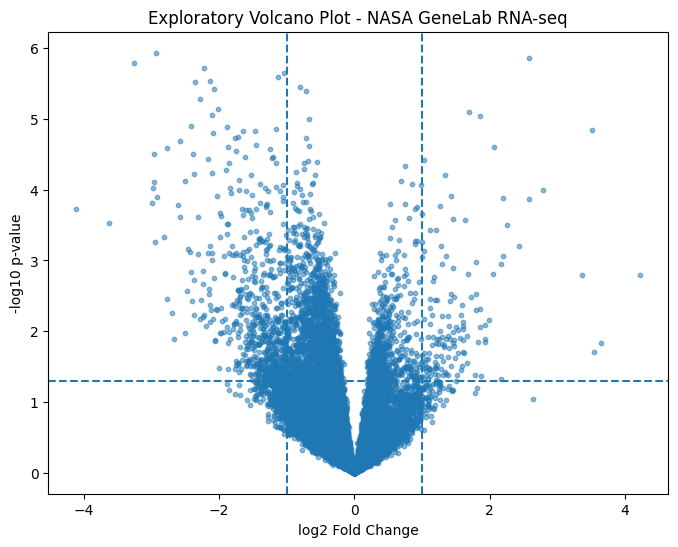

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    de_results["log2FC"],
    de_results["neg_log10_pvalue"],
    alpha=0.5,
    s=10
)

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Exploratory Volcano Plot - NASA GeneLab RNA-seq")

plt.savefig("figures/volcano_plot.png", dpi=300, bbox_inches="tight")

plt.show()

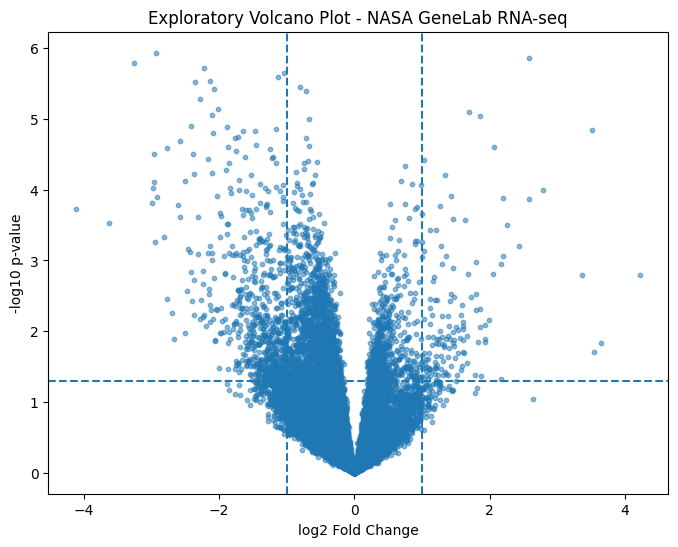

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    de_results["log2FC"],
    de_results["neg_log10_pvalue"],
    alpha=0.5,
    s=10
)

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Exploratory Volcano Plot - NASA GeneLab RNA-seq")

plt.savefig("figures/volcano_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
# significance thresholds
fc_threshold = 1
p_threshold = 0.05

de_results["significant"] = "Not Significant"

de_results.loc[
    (de_results["log2FC"] > fc_threshold) &
    (de_results["pvalue"] < p_threshold),
    "significant"
] = "Upregulated"

de_results.loc[
    (de_results["log2FC"] < -fc_threshold) &
    (de_results["pvalue"] < p_threshold),
    "significant"
] = "Downregulated"

de_results["significant"].value_counts()

significant
Not Significant    56381
Downregulated        670
Upregulated          135
Name: count, dtype: int64

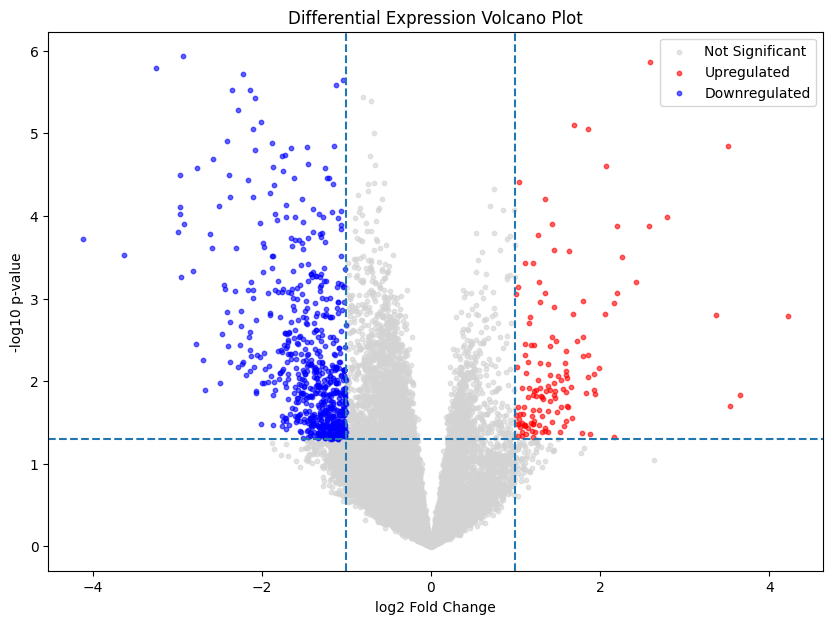

In [15]:
colors = {
    "Not Significant": "lightgray",
    "Upregulated": "red",
    "Downregulated": "blue"
}

plt.figure(figsize=(10,7))

for category, color in colors.items():
    subset = de_results[de_results["significant"] == category]

    plt.scatter(
        subset["log2FC"],
        subset["neg_log10_pvalue"],
        c=color,
        label=category,
        alpha=0.6,
        s=10
    )

plt.axvline(x=1, linestyle="--")
plt.axvline(x=-1, linestyle="--")
plt.axhline(y=-np.log10(0.05), linestyle="--")

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 p-value")
plt.title("Differential Expression Volcano Plot")

plt.legend()

plt.savefig("figures/volcano_plot_colored.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [16]:
top_genes = de_results.sort_values(
    by="pvalue"
).head(20)

top_genes

,gene,log2FC,pvalue,neg_log10_pvalue,significant
38490,ENSMUSG00000103753,-1.000000,0.000000,inf,Not Significant
2065,ENSMUSG00000019232,-2.924681,0.000001,5.934350,Downregulated
28721,ENSMUSG00000088689,2.585274,0.000001,5.859913,Upregulated
11011,ENSMUSG00000038203,-3.254560,0.000002,5.790054,Downregulated
15904,ENSMUSG00000055415,-2.226350,0.000002,5.723490,Downregulated
12835,ENSMUSG00000043342,-1.038780,0.000002,5.646346,Downregulated
4299,ENSMUSG00000024112,-1.124923,0.000003,5.591396,Downregulated
39531,ENSMUSG00000104901,-2.135630,0.000003,5.530751,Downregulated
16063,ENSMUSG00000056162,-2.355952,0.000003,5.525540,Downregulated
2730,ENSMUSG00000020788,-0.808236,0.000004,5.446009,Not Significant


In [17]:
top_genes.to_csv("top_genes.csv", index=False)

In [18]:
# ## Preliminary Findings

# Exploratory differential expression analysis identified several significantly upregulated and downregulated genes between experimental groups.

# PCA analysis suggested transcriptional differences between subsets of NASA GeneLab samples, potentially associated with spaceflight-related biological effects.

In [19]:
top_gene_names = top_genes["gene"].head(20)

heatmap_data = log_expr.loc[top_gene_names]

heatmap_data.head()

,GSM5398358,GSM5398359,GSM5398360,GSM5398361,GSM5398362,GSM5398363,GSM5398364,GSM5398365,GSM5398366,GSM5398367,GSM5398368,GSM5398369
gene,,,,,,,,,,,,
ENSMUSG00000103753,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000019232,2.584963,3.169925,2.807355,2.584963,3.700440,3.700440,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
ENSMUSG00000088689,4.169925,4.754888,4.807355,5.129283,5.169925,5.491853,7.219169,7.948367,7.149747,7.409391,7.693487,7.614710
ENSMUSG00000038203,5.584963,5.357552,5.954196,6.129283,5.700440,5.614710,2.321928,3.000000,2.584963,3.000000,2.321928,1.584963
ENSMUSG00000055415,2.321928,2.807355,2.321928,2.000000,2.321928,2.584963,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [20]:
top_gene_names = top_genes["gene"].head(20)

heatmap_data = log_expr.loc[top_gene_names]

heatmap_data.head()

,GSM5398358,GSM5398359,GSM5398360,GSM5398361,GSM5398362,GSM5398363,GSM5398364,GSM5398365,GSM5398366,GSM5398367,GSM5398368,GSM5398369
gene,,,,,,,,,,,,
ENSMUSG00000103753,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSMUSG00000019232,2.584963,3.169925,2.807355,2.584963,3.700440,3.700440,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
ENSMUSG00000088689,4.169925,4.754888,4.807355,5.129283,5.169925,5.491853,7.219169,7.948367,7.149747,7.409391,7.693487,7.614710
ENSMUSG00000038203,5.584963,5.357552,5.954196,6.129283,5.700440,5.614710,2.321928,3.000000,2.584963,3.000000,2.321928,1.584963
ENSMUSG00000055415,2.321928,2.807355,2.321928,2.000000,2.321928,2.584963,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


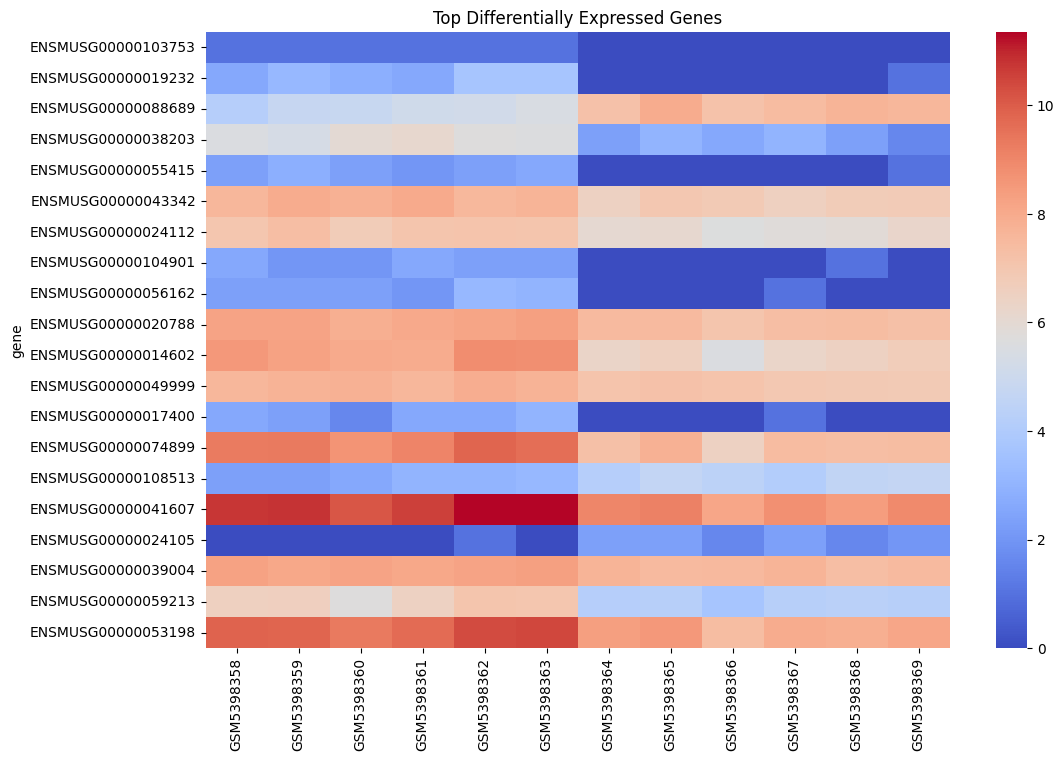

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm"
)

plt.title("Top Differentially Expressed Genes")

plt.savefig(
    "figures/heatmap_top_genes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()